# 🧠 Session 8 — Interaction Effects, Nonlinearity & Model Flexibility

### Goals for this session:
- Understand what interaction terms are and why they matter  
- Build polynomial models to capture curved relationships  
- Visualize nonlinearity using residual patterns  
- Fit spline regressions to capture flexible curvature  
- Fit a GAM (Generalized Additive Model)  
- Use PDP & ICE plots to interpret nonlinear models  
- Compare model performance: linear vs polynomial vs GAM  


In [1]:
# --- 1. Import libraries ---
import os
import sys
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

# Manually define the correct project root path based on your previous output
CORRECT_PROJECT_ROOT = "/home/rtackett/projects/Masters-level-DIY-Data-Science-Curriculum-ai-Era-/ds-zero-to-one"

# Set CWD
try:
    os.chdir(CORRECT_PROJECT_ROOT)
    print(f"✅ CWD successfully set to: {os.getcwd()}")

    # Add to sys.path for module imports (src.helpers)
    if CORRECT_PROJECT_ROOT not in sys.path:
        sys.path.append(CORRECT_PROJECT_ROOT)
        print("✅ Added project root to sys.path.")

except FileNotFoundError:
    print("❌ CRITICAL ERROR: The manually defined project path does not exist.")
    sys.exit(1)

✅ CWD successfully set to: /home/rtackett/projects/Masters-level-DIY-Data-Science-Curriculum-ai-Era-/ds-zero-to-one
✅ Added project root to sys.path.


In [12]:
import pandas as pd

df = pd.read_csv("data/processed/tips_synthetic.csv")

# Encode gender/smoker safely
df_work = df.copy()

if "gender" in df_work.columns and "gender_Male" not in df_work.columns:
    df_work = pd.get_dummies(df_work, columns=["gender"], prefix="gender", drop_first=True)

if "is_smoker" in df_work.columns and "is_smoker_Yes" not in df_work.columns:
    df_work = pd.get_dummies(df_work, columns=["is_smoker"], prefix="is_smoker", drop_first=True)

features = ["bill_total_usd", "party_size", "gender_Male", "is_smoker_Yes"]
X = df_work[features]
y = df_work["tip_usd"]

df_work.head()

,bill_total_usd,party_size,tip_usd,tip_pct,gender_Male,is_smoker_Yes
0,43.71,1,3.65,0.084,False,True
1,95.56,4,9.88,0.103,True,False
2,75.88,2,7.78,0.103,False,False
3,63.88,4,12.78,0.200,True,False
4,24.04,2,4.36,0.181,False,False


In [4]:
import pandas as pd
import statsmodels.formula.api as smf

df_int = df_work.copy()

# Interaction model: bill * party_size
model_int = smf.ols(
    formula="tip_usd ~ bill_total_usd * party_size + gender_Male + is_smoker_Yes",
    data=df_int
).fit()

model_int.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                tip_usd   R-squared:                       0.514
Model:                            OLS   Adj. R-squared:                  0.507
Method:                 Least Squares   F-statistic:                     83.22
Date:                Thu, 27 Nov 2025   Prob (F-statistic):           1.68e-59
Time:                        09:37:47   Log-Likelihood:                -914.25
No. Observations:                 400   AIC:                             1841.
Df Residuals:                     394   BIC:                             1864.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
=============================================================================================
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                     2.1113      0.633      3.333      0.001       0.866       3.357
gender_Male[T.True]          -0.1951      0.241     -0.808      0.419      -0.670       0.280
is_smoker_Yes[T.True]        -0.6807      0.263     -2.584      0.010      -1.199      -0.163
bill_total_usd                0.0819      0.010      8.138      0.000       0.062       0.102
party_size                   -0.0786      0.216     -0.363      0.716      -0.504       0.347
bill_total_usd:party_size     0.0032      0.003      0.937      0.349      -0.004       0.010
==============================================================================
Omnibus:                        1.720   Durbin-Watson:                   2.059
Prob(Omnibus):                  0.423   Jarque-Bera (JB):                1.810
Skew:                           0.142   Prob(JB):                        0.405
Kurtosis:                       2.833   Cond. No.                     1.02e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.02e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

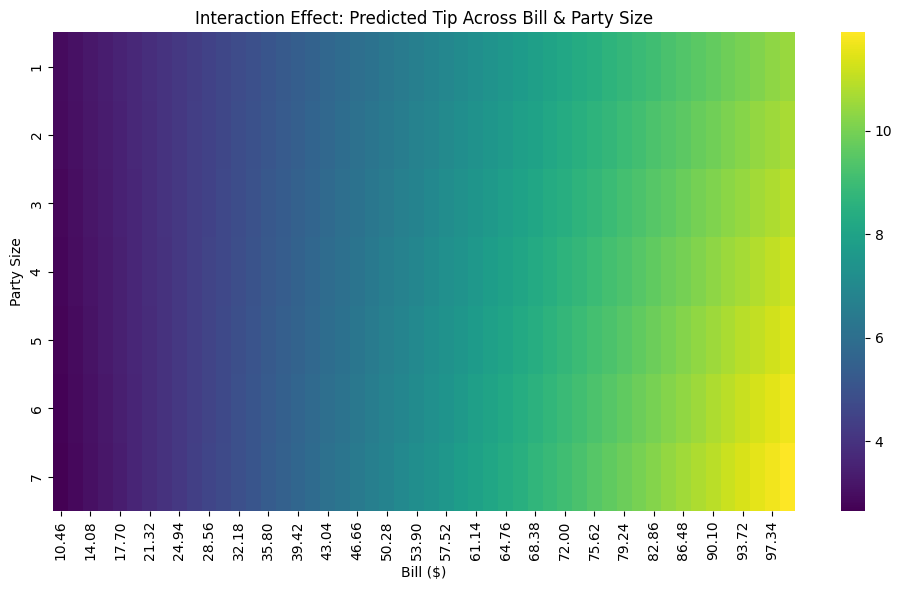

In [7]:
# Create grid for bill & party size
bill_grid = np.linspace(df.bill_total_usd.min(), df.bill_total_usd.max(), 50)
party_grid = np.arange(1, 8)
B, P = np.meshgrid(bill_grid, party_grid)

grid_df = pd.DataFrame({
    "bill_total_usd": B.ravel(),
    "party_size": P.ravel(),
    "gender_Male": 0,        # hold constant
    "is_smoker_Yes": 0
})

grid_df["pred"] = model_int.predict(grid_df)

plt.figure(figsize=(10,6))
ax = sns.heatmap(
    grid_df.pivot_table(
        index="party_size",
        columns="bill_total_usd",
        values="pred"
    ),
    cmap="viridis"
)

plt.title("Interaction Effect: Predicted Tip Across Bill & Party Size")
plt.xlabel("Bill ($)")
plt.ylabel("Party Size")

# ---- NEW: Round x-axis labels to ##.## format ----
ax.set_xticklabels([f"{float(t.get_text()):.2f}" for t in ax.get_xticklabels()])

plt.tight_layout()
plt.show()


### 🍼 ELI5: What is an interaction?

Imagine **two knobs** controlling tip amount:
- One knob = bill size  
- One knob = party size  

Turning either knob changes tips.  
But **an interaction means the knobs affect each other.**

Example:  
- A big bill might increase tips *a lot* for small tables  
- But *barely increase* tips for large tables  

So the effect of one variable depends on the level of another.


In [8]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np

poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(df[["bill_total_usd"]])
y = df["tip_usd"]

model_poly = LinearRegression().fit(X_poly, y)
y_pred = model_poly.predict(X_poly)

print("R² Poly:", r2_score(y, y_pred))
print("R² Linear:", r2_score(y, LinearRegression().fit(df[["bill_total_usd"]], y).predict(df[["bill_total_usd"]])))


R² Poly: 0.5017336967374468
R² Linear: 0.5013981355423012


/home/rtackett/miniconda3/envs/ds/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


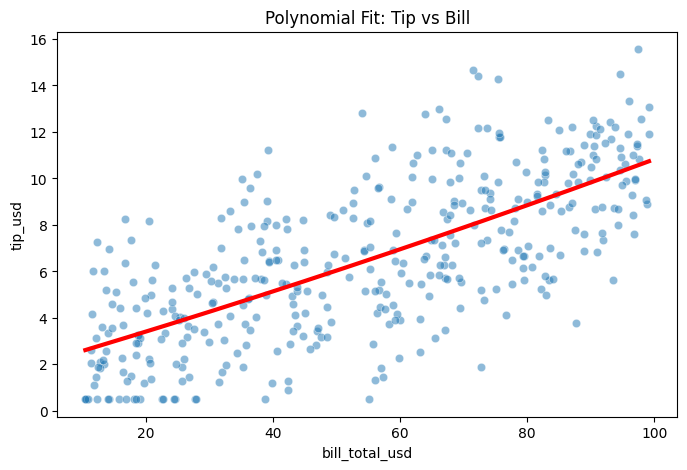

In [9]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df.bill_total_usd, y=df.tip_usd, alpha=0.5)

bill_sorted = np.sort(df.bill_total_usd)
bill_poly_sorted = poly.transform(bill_sorted.reshape(-1,1))
plt.plot(bill_sorted, model_poly.predict(bill_poly_sorted), color="red", lw=3)

plt.title("Polynomial Fit: Tip vs Bill")
plt.show()


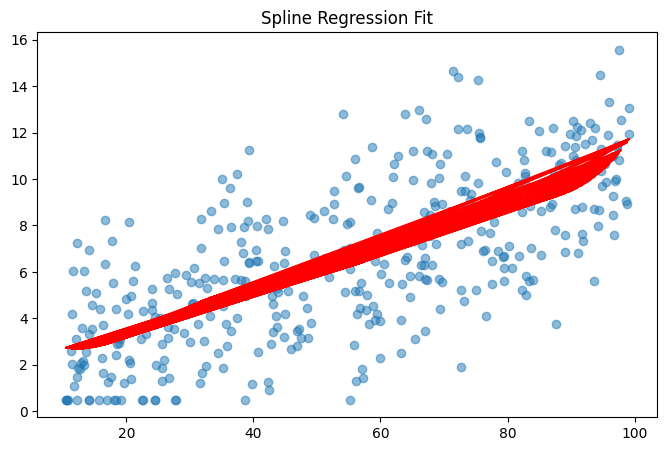

In [10]:
from patsy import dmatrix
import statsmodels.api as sm

x_spline = dmatrix("bs(bill_total_usd, df=6, degree=3)", data=df, return_type='dataframe')

spl_model = sm.OLS(y, x_spline).fit()

plt.figure(figsize=(8,5))
plt.scatter(df.bill_total_usd, df.tip_usd, alpha=0.5)
plt.plot(df.bill_total_usd, spl_model.predict(x_spline), color='red')
plt.title("Spline Regression Fit")
plt.show()


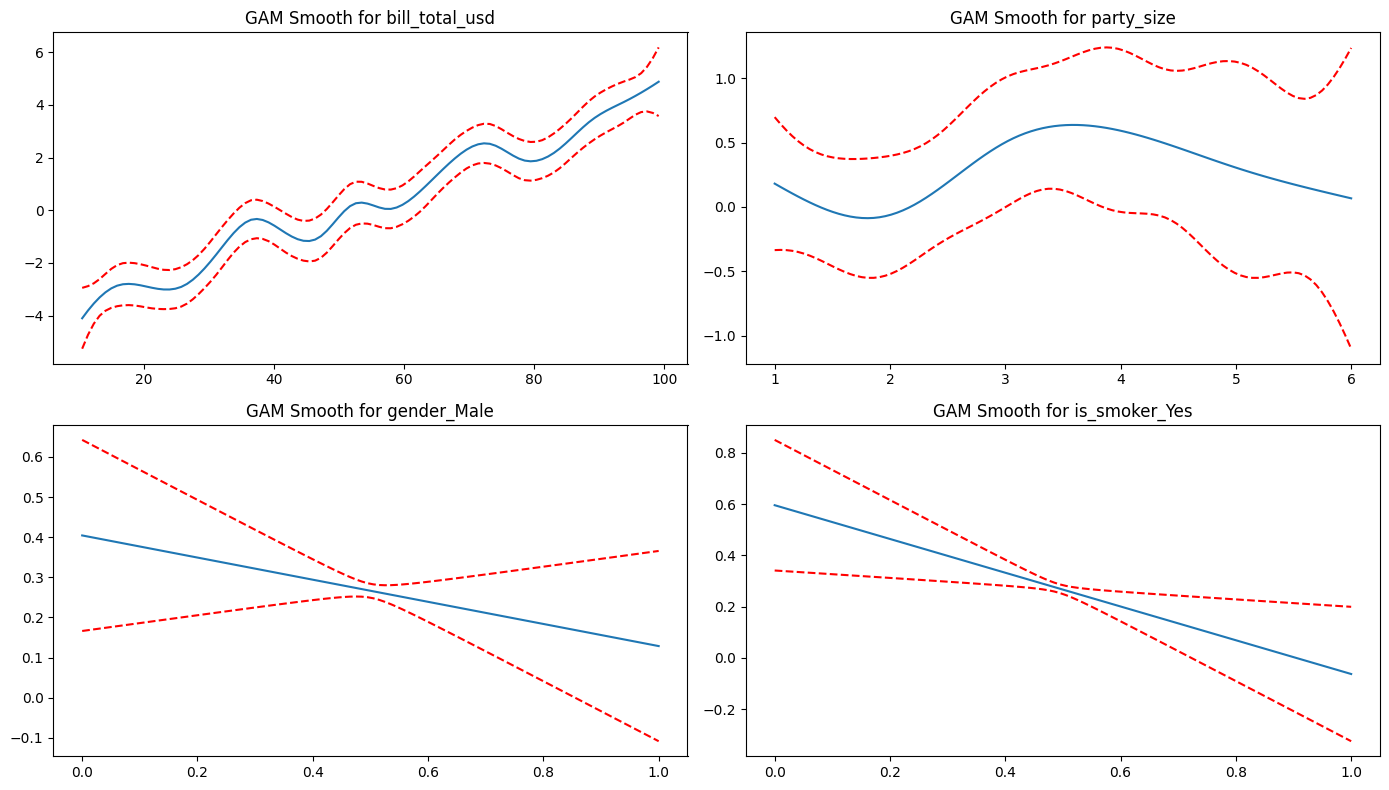

In [15]:
#With Confidence Intervals

!pip install pygam
from pygam import LinearGAM, s
import matplotlib.pyplot as plt

# Fit the GAM
gam = LinearGAM(s(0) + s(1) + s(2) + s(3)).fit(df_work[features], y)

# # Plot each smooth term
# plt.figure(figsize=(14,8))

# for i, feature in enumerate(features):
#     plt.subplot(2, 2, i+1)
#     gam.plot_partial(i)
#     plt.title(f"Partial Dependence: {feature}")

# plt.tight_layout()
# plt.show()

plt.figure(figsize=(14,8))

for i, feature in enumerate(features):
    plt.subplot(2, 2, i+1)
    XX = gam.generate_X_grid(term=i)
    plt.plot(XX[:, i], gam.partial_dependence(term=i, X=XX))
    plt.plot(XX[:, i], gam.partial_dependence(term=i, X=XX, width=.95)[1], c='r', linestyle='--')
    plt.title(f"GAM Smooth for {feature}")

plt.tight_layout()
plt.show()



In [18]:
gam.summary()

import warnings
warnings.filterwarnings(
    "ignore",
    message="KNOWN BUG: p-values computed in this summary are likely much smaller than they should be."
)
gam.summary()


LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     19.5062
Link Function:                     IdentityLink Log Likelihood:                                 -1086.3635
Number of Samples:                          400 AIC:                                             2213.7395
                                                AICc:                                            2216.0698
                                                GCV:                                                6.0646
                                                Scale:                                              5.5347
                                                Pseudo R-Squared:                                   0.5476
Feature Function                  Lam

> ⚠️ Note: `pygam`’s `summary()` prints p-values for each smooth term,  
> but the library warns that these p-values are unreliable.  
> For this course, I’m using GAMs for *shape exploration* (nonlinear patterns)  
> and not for formal significance testing.


## Nonlinear Relationships with Generalized Additive Models (GAM)

**Goal:** See whether the relationship between our predictors and `tip_usd`
is really straight-line, or if there are gentle curves that a linear model misses.

**What is a GAM (Generalized Additive Model)?**

- A GAM lets each feature have its **own smooth curve** instead of a single slope.
- The model looks like:

    $\hat{y} = \beta_0 + f_1(x_1) + f_2(x_2) + \dots + f_p(x_p)$

  
<!-- 
  \[
  \hat{y} = \beta_0 + f_1(x_1) + f_2(x_2) + \dots + f_p(x_p)
  \] -->

  <!-- where each \( f_j(\cdot) \) is a smooth (possibly wiggly) function. -->
where each $f_j(\cdot)$ is a smooth (possibly wiggly) function.

- This is great when:
  - A small bill behaves differently than a huge bill.
  - Tiny parties behave differently than large parties.
  - We don’t want to hand-engineer polynomial and interaction terms.

**Important caveat (pyGAM):**

> `pygam` warns that the p-values in `gam.summary()` are not reliable.  
> In this notebook, I’m using GAMs to **look at shapes** (pattern detection),
> not to make hard “this is statistically significant” claims.


In [19]:
import numpy as np
import pandas as pd

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

from pygam import LinearGAM, s

# --- 1) Features & target ---
X = df_work[features].copy()
y = df_work["tip_usd"].copy()

# Train / test split (keep it simple)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# --- 2) Baseline linear regression ---
lin = LinearRegression()
lin.fit(X_train, y_train)

y_hat_train_lin = lin.predict(X_train)
y_hat_test_lin  = lin.predict(X_test)

rmse_train_lin = np.sqrt(mean_squared_error(y_train, y_hat_train_lin))
rmse_test_lin  = np.sqrt(mean_squared_error(y_test,  y_hat_test_lin))
r2_train_lin   = r2_score(y_train, y_hat_train_lin)
r2_test_lin    = r2_score(y_test,  y_hat_test_lin)

# --- 3) GAM with smooth terms on each feature ---
# s(0) means "smooth for column 0", etc.
gam = LinearGAM(
    s(0) + s(1) + s(2) + s(3)
).fit(X_train.values, y_train.values)

y_hat_train_gam = gam.predict(X_train.values)
y_hat_test_gam  = gam.predict(X_test.values)

rmse_train_gam = np.sqrt(mean_squared_error(y_train, y_hat_train_gam))
rmse_test_gam  = np.sqrt(mean_squared_error(y_test,  y_hat_test_gam))
r2_train_gam   = r2_score(y_train, y_hat_train_gam)
r2_test_gam    = r2_score(y_test,  y_hat_test_gam)

print("=== Baseline Linear Regression ===")
print(f"Train: R²={r2_train_lin:.3f}, RMSE={rmse_train_lin:.3f}")
print(f"Test:  R²={r2_test_lin:.3f},  RMSE={rmse_test_lin:.3f}")
print()
print("=== GAM (with smooth terms) ===")
print(f"Train: R²={r2_train_gam:.3f}, RMSE={rmse_train_gam:.3f}")
print(f"Test:  R²={r2_test_gam:.3f},  RMSE={rmse_test_gam:.3f}")


=== Baseline Linear Regression ===
Train: R²=0.543, RMSE=2.351
Test:  R²=0.387,  RMSE=2.492

=== GAM (with smooth terms) ===
Train: R²=0.578, RMSE=2.259
Test:  R²=0.384,  RMSE=2.499


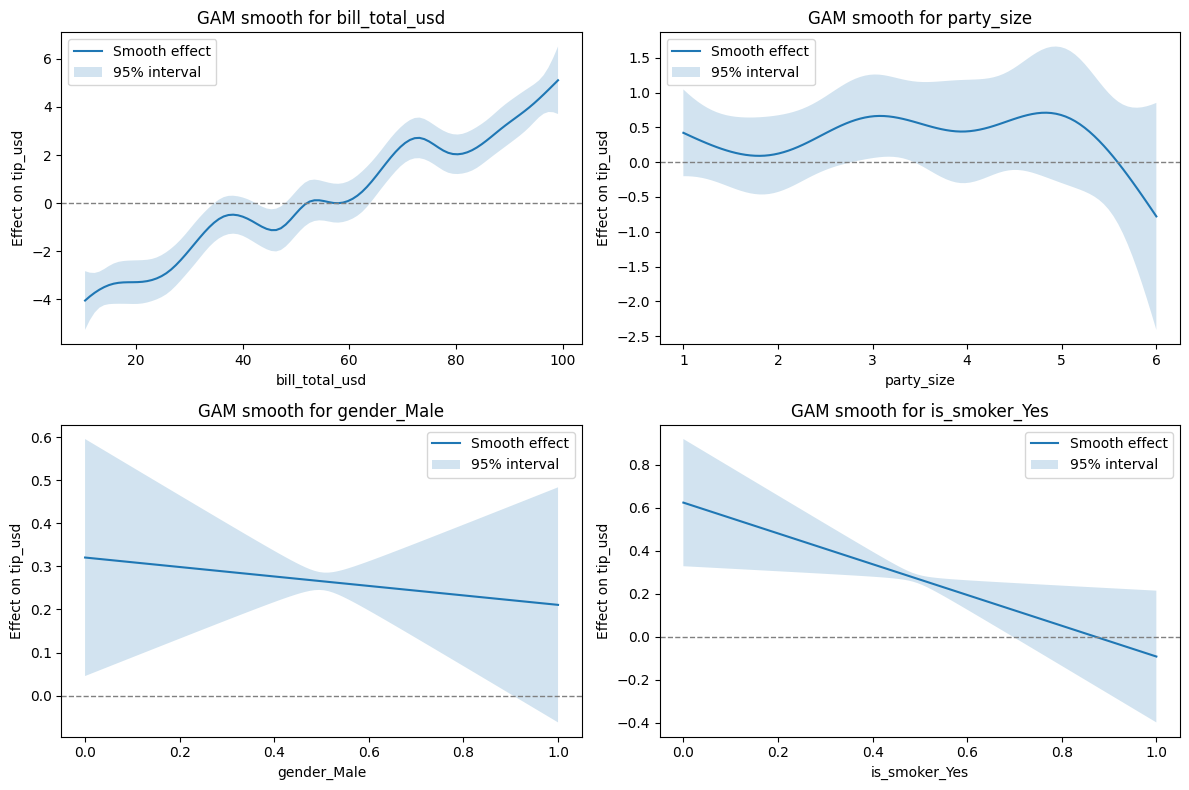

In [30]:
import numpy as np
import matplotlib.pyplot as plt

feature_names = ["bill_total_usd", "party_size", "gender_Male", "is_smoker_Yes"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for i, ax in enumerate(axes):
    # 1) Generate a grid for this term
    XX = gam.generate_X_grid(term=i)
    
    # 2) Get partial dependence + 95% confidence interval
    pdep, confi = gam.partial_dependence(term=i, X=XX, width=0.95)
    # confi is shape (n_points, 2): [:, 0] = lower, [:, 1] = upper
    lower = confi[:, 0]
    upper = confi[:, 1]

    # 3) Plot smooth line
    ax.plot(XX[:, i], pdep, label="Smooth effect")

    # 4) Shaded 95% interval
    ax.fill_between(
        XX[:, i],
        lower,
        upper,
        alpha=0.2,
        label="95% interval"
    )

    ax.axhline(0, color="gray", linestyle="--", linewidth=1)
    ax.set_xlabel(feature_names[i])
    ax.set_ylabel("Effect on tip_usd")
    ax.set_title(f"GAM smooth for {feature_names[i]}")
    ax.legend()

plt.tight_layout()
plt.show()


In [ ]:
# #TRIED TO SWITCH TO GEMINI AND GOT GARBAGE TOO

# import matplotlib.pyplot as plt
# import numpy as np # <-- Added numpy import

# # Assuming 'features' is your list of feature names and 'gam' is your fitted GAM model
# # feature_names = features # re-use your list - Assuming this is defined earlier

# # --- Start of the corrected plotting code ---

# fig, axes = plt.subplots(2, 2, figsize=(12, 8))
# axes = axes.ravel() # Flatten the 2x2 array of axes for easy iteration

# for i, ax in enumerate(axes):
#     # Check if we have more subplots than features
#     if i >= len(feature_names):
#         ax.axis("off") # Turn off unused subplots
#         continue
    
#     # 1D grid for this feature
#     XX = gam.generate_X_grid(term=i)
    
#     # Calculate partial dependence and 95% confidence interval
#     # Note: When width is specified, gam.partial_dependence returns (pdep, lower_bound, upper_bound)
    
#     # Option 1: Unpack into three variables (Cleanest for PyGAM)
#     pdep, lower_bound, upper_bound = gam.partial_dependence(term=i, X=XX, width=0.95)

#     # Option 2: Use conf[0] and conf[1] and squeeze (As requested, using squeeze for robustness)
#     # conf = gam.partial_dependence(term=i, X=XX, width=0.95)
#     # pdep = conf[0] # Note: When using this method, pdep is conf[0] if width is NOT specified. 
#                      # With width, conf is a tuple of (pdep, lower, upper), so pdep is the first element.
#                      # However, to be safe and clear, let's stick to the 3-variable unpacking above
#                      # as it is the standard way to handle the output when 'width' is used.

#     # If the partial dependence function returns arrays with shape (N, 1), 
#     # we use np.squeeze() to reduce them to a 1D array of shape (N,) 
#     # as required by Matplotlib's fill_between.
    
#     # lower_bound_1d = np.squeeze(lower_bound)
#     # upper_bound_1d = np.squeeze(upper_bound)
#     XX_1d = np.squeeze(XX[:, i])
    
#     # Plot the smooth effect
#     ax.plot(XX_1d, pdep, label="Smooth effect")
    
#     # Plot the 95% confidence interval
#     # ax.fill_between(
#     #     XX_1d,
#     #     lower_bound_1d, # The corrected 1D lower bound
#     #     upper_bound_1d, # The corrected 1D upper bound
#     #     alpha=0.2,
#     #     label="95% interval"
#     # )
    
#     # Add auxiliary lines and labels
#     ax.axhline(0, color="gray", linestyle="--", linewidth=1)
#     ax.set_xlabel(feature_names[i])
#     ax.set_ylabel("Effect on predicted tip")
#     ax.set_title(f"GAM Smooth for {feature_names[i]}")
#     ax.legend()

# plt.suptitle("GAM Smooths — How each feature influences tip_usd", y=1.02, fontsize=14)
# plt.tight_layout()
# plt.show()

In [ ]:
# from datetime import datetime

# try:
#     from src.helpers import save_and_log_plot
#     fig = plt.gcf()  # get current figure

#     save_and_log_plot(
#         fig,
#         "reports/figures/gam_smooths_tip_usd.png",
#         df=df_work,
#         chart_type="gam_smooths",
#         library="pygam+matplotlib",
#         x="features",
#         y="smooth_effect",
#         dataset_name="tips_synthetic",
#         dataset_path="data/processed/tips_synthetic.csv",
#         notebook="notebooks/08_Nonlinearities_and_GAMs.ipynb",
#         notes="GAM partial dependence for bill_total_usd, party_size, gender_Male, is_smoker_Yes.",
#         timestamped=True,
#     )
# except Exception as e:
#     print(f"(Optional logging skipped) Reason: {e.__class__.__name__}: {e}")


In [31]:
from src.helpers import save_and_log_plot

save_and_log_plot(
    fig,
    "reports/figures/gam_smooths_tip_usd.png",  # base name; helper adds timestamp
    df=df_work[features].copy(),
    chart_type="gam_smooths",
    library="matplotlib + pygam",
    x="(multiple features)",
    y="tip_usd",
    dataset_name="tips_synthetic",
    dataset_path="data/processed/tips_synthetic.csv",
    notebook="notebooks/08_Nonlinearity_and_GAMs.ipynb",
    notes="GAM partial dependence plots for bill, party size, gender, smoker."
)


✅ Saved Matplotlib figure to: reports/figures/gam_smooths_tip_usd_2025-11-27_1744.png
📝 Logged metadata → reports/figures/gam_smooths_tip_usd_2025-11-27_1744.json


(PosixPath('reports/figures/gam_smooths_tip_usd_2025-11-27_1744.png'),
 PosixPath('reports/figures/gam_smooths_tip_usd_2025-11-27_1744.json'))

📈 Generalized Additive Models (GAMs) — Smooth Non-Linear Effects

A Generalized Additive Model (GAM) lets each predictor have its own smooth, flexible curve instead of forcing everything into a straight-line relationship like OLS.

This makes GAMs excellent when you suspect non-linearity, plateaus, or subtle bends in your data.

🔢 Model Form

Each term is a learned curve showing how that variable nudges the prediction up or down, holding everything else constant.

🧠 Why GAMs?

* They **capture non-linear patterns** with smooth splines.
* You don’t have to hand-engineer polynomial terms.
* They offer **interpretability**: one plot per feature.
* They generalize better than unrestricted non-linear models.
GAMs sit in the sweet spot between **simple OLS** and **fully flexible ML models**.

📊 Smooth Effects Plot
Each panel shows how the model “wiggles” a variable to improve predictions:
* **x-axis**: the value of the feature
* **y-axis**: the estimated change in tip amount (tip_usd)
* **Blue line**: smooth learned effect
* **Shaded band**: 95% confidence interval
* **Gray dashed line**: no effect

🧒 ELI5 Interpretation
* **Bill total** (bill_total_usd)
→ Higher bills ≈ higher tips, but not perfectly straight.
GAM picks up little wiggles where OLS forces a line.
* **Party size** (party_size)
→ Slight non-linear effects: increases for mid-size groups, uncertainty at large groups.
* **Gender** (gender_Male)
→ Almost no effect. Wide confidence band = model shrug.

Smoker (is_smoker_Yes)
→ Slight negative effect, but small and uncertain.

🧩 When to Use GAMs
Use a GAM when you want:
* flexible curves
* interpretability
* less risk of overfitting than polynomial regressions
* clean partial dependence plots
* transparency of “which feature bends the prediction—where?”

GAMs are a powerful, interpretable extension of linear models.